In [117]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn import preprocessing
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


%config InlineBackend.figure_format='retina'
plt.rc('text', usetex=True)

### Time to get your hands dirty. SDSS Galaxies vs quasars

We're now going to classify galaxy vs quasars in the Sloan Digital Sky Survey. 


#### Data

The dataset is at `solutions/galaxyquasar.csv`. I have extracted it myself from the SDSS database using the SQL query reported [here](https://www.astroml.org/_modules/astroML/datasets/sdss_galaxy_colors.html#fetch_sdss_galaxy_colors)

(If you've never used [SQL](https://en.wikipedia.org/wiki/SQL) and want to learn something new in computing, it's very powerful)

#### Tasks

- Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
- Remember to split the dataset into training and validation...

#### Ideas
- Try using different colors (a subset of them first, than all together). Which is the most important feature?
- What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?


In [67]:
df = pd.read_csv('../solutions/galaxyquasar.csv')

In [68]:
df

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [69]:
ug = np.array(df['u']-df['g'])
gr = np.array(df['g']-df['r'])
ri = np.array(df['r']-df['i'])
iz = np.array(df['i']-df['z'])

colors = [ug,gr,ri,iz]
cl = np.array(df['class'])

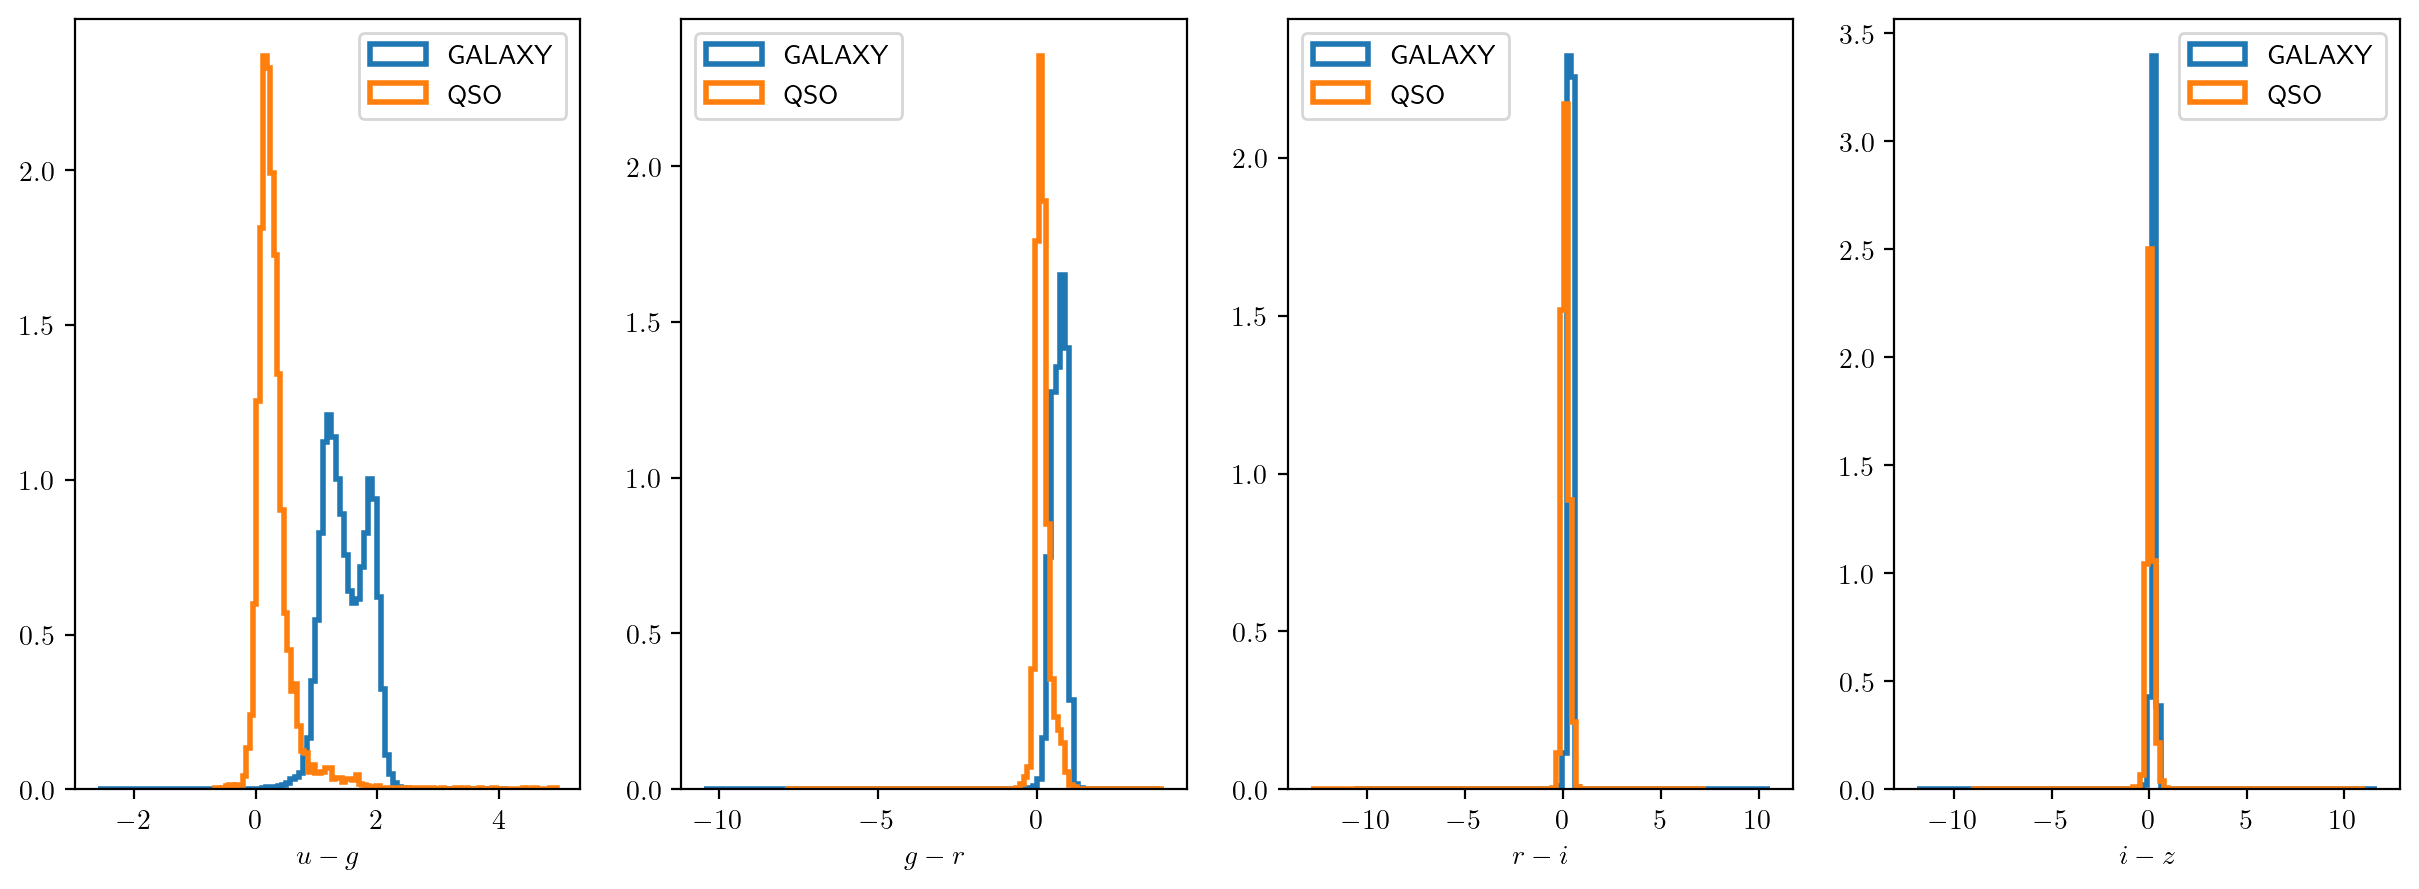

In [70]:
fig, ax = plt.subplots(1,4, figsize = [15,5])
cnames = ['$u-g$', '$g-r$', '$r-i$', '$i-z$']
for i in range(4):
    ax[i].hist(colors[i][cl == 'GALAXY'], bins = 100, density = True, label = 'GALAXY', histtype = 'step', lw = 2)
    ax[i].hist(colors[i][cl == 'QSO'], bins = 100, density = True, label = 'QSO', histtype = 'step', lw = 2)
    ax[i].set_xlabel(cnames[i])
    ax[i].legend()


In [71]:
le = preprocessing.LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df['class'] = le.fit_transform(df['class'])
labels = le.inverse_transform(df['class'])
class_names = le.classes_
print(class_names)

['GALAXY' 'QSO']


Text(0, 0.5, 'True positive rate')

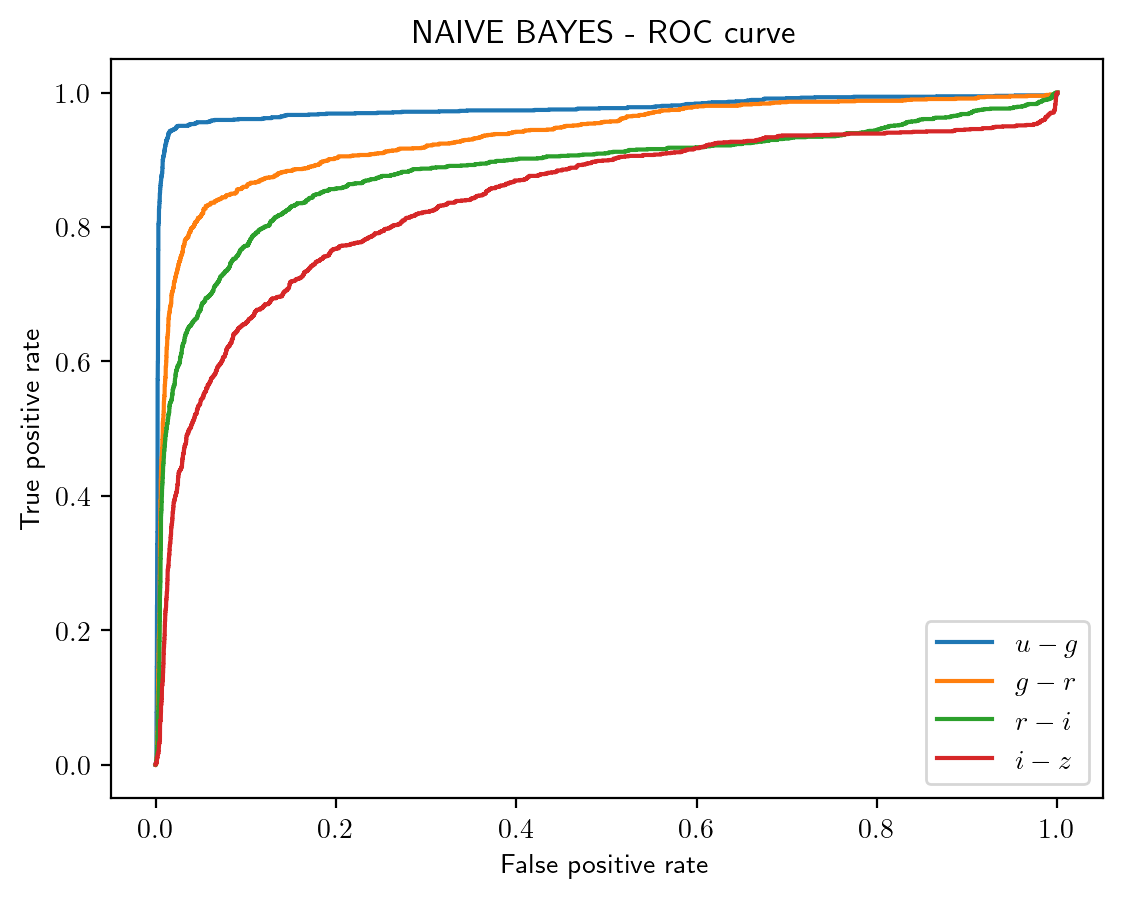

In [ ]:
# NAIVE BAYES : assuming all features are independent

for i in range(4):

    X = (colors[i])[:,np.newaxis]
    y = df['class']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    gnb = GaussianNB()
    gnb_fit = gnb.fit(X_train, y_train)
    y_prob = gnb_fit.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label = cnames[i])

plt.legend()
plt.title('NAIVE BAYES - ROC curve')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')

Maximum accuracy: 0.9824
Best model n =  14


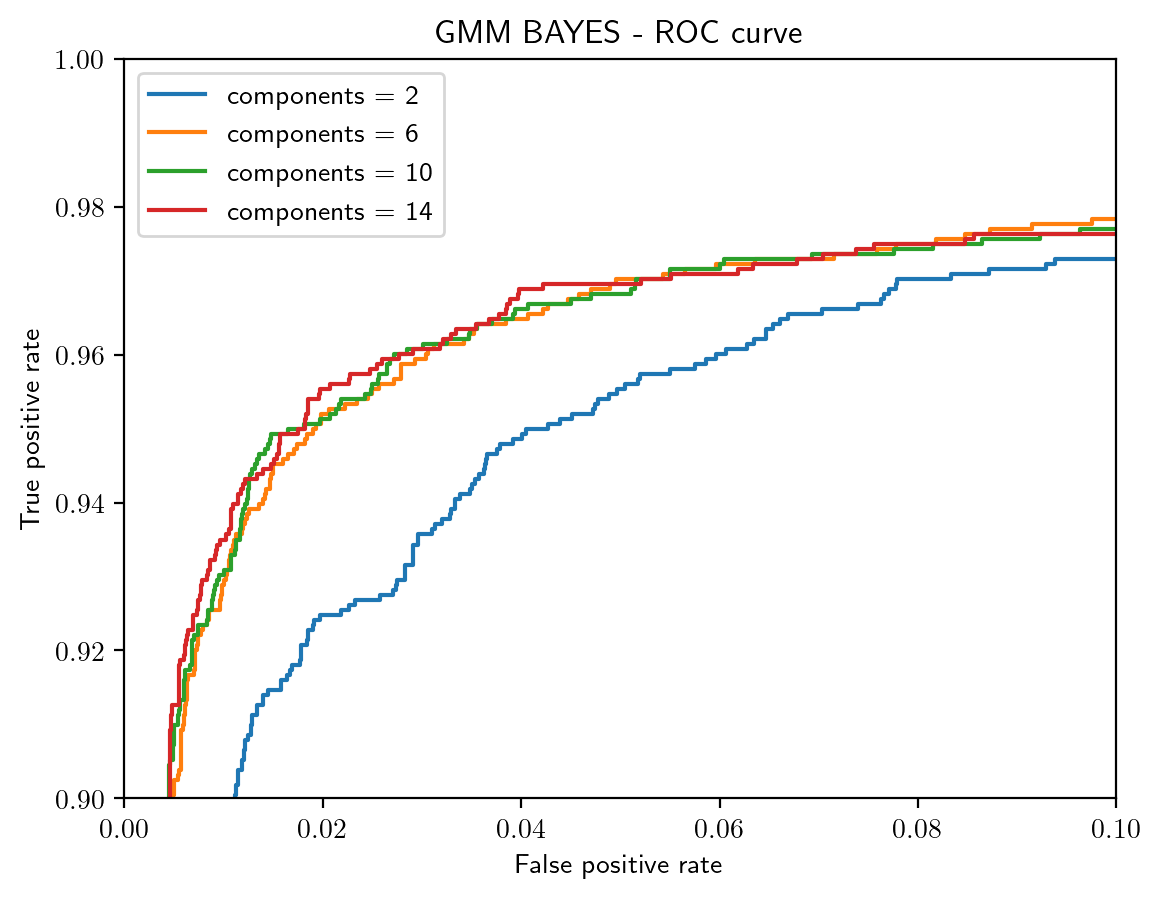

In [126]:
# GAUSSIAN MIXTURE MODEL BAYES

acc = []
n_values = np.arange(2,16)[::4]

for n in n_values:

    X = np.array(colors).T
    y = df['class']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    gmmb = GMMBayes(n) # clusters per class
    gmmb.fit(X_train,y_train)
    y_prob = gmmb.predict_proba(X_test)[:,1]
    y_pred = gmmb.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label = f'components = {n}')
    cm = confusion_matrix(y_test, y_pred)
    acc.append(np.trace(cm)/len(y_test))

plt.legend()
plt.title('GMM BAYES - ROC curve')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.ylim(0.9,1.)
plt.xlim(0.,0.1)

idx = np.argmax(acc)
print('Maximum accuracy:', acc[idx])
print('Best model n = ', n_values[idx])

Maximum accuracy: 0.9841
Best model n =  6


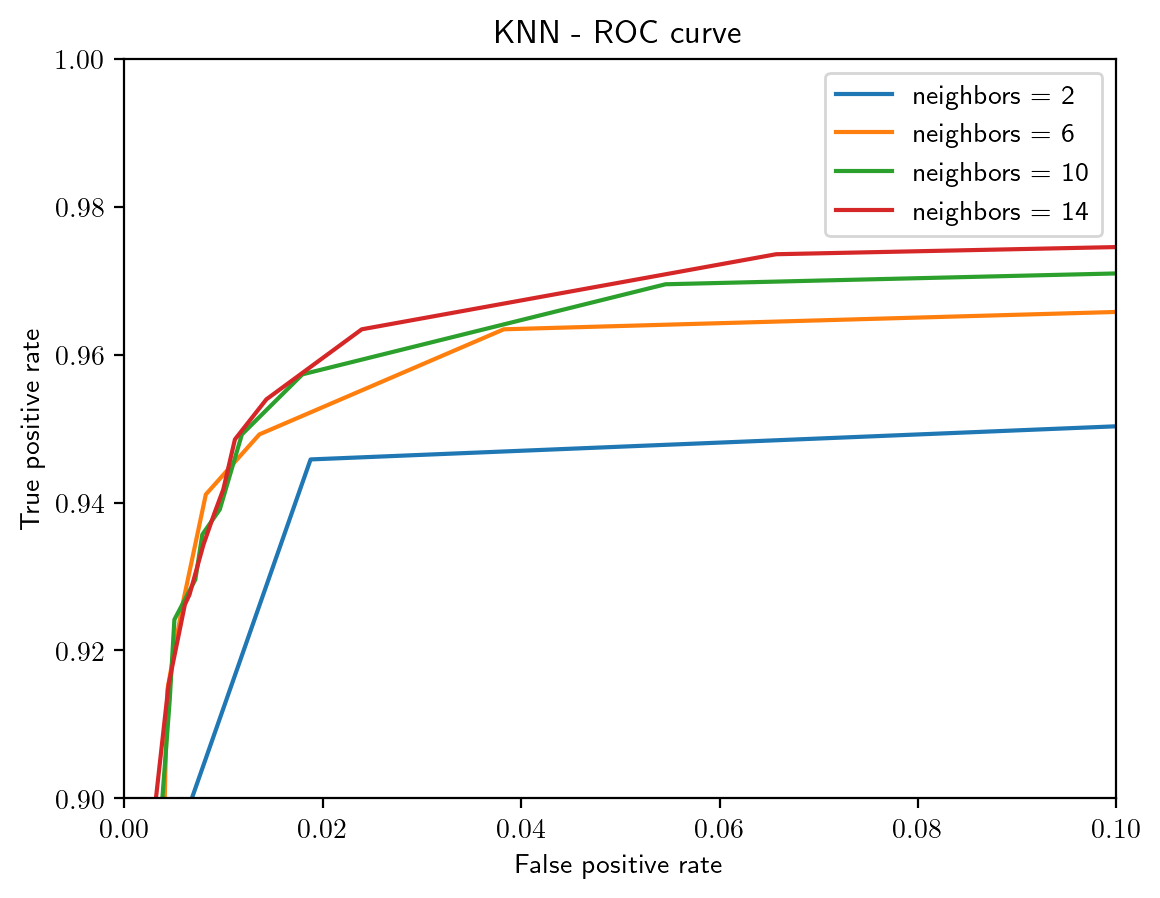

In [124]:
acc = []
k_values = np.arange(2,16)[::4]

for k in k_values:

    X = np.array(colors).T
    y = df['class']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    knc = KNeighborsClassifier(k) # number of neighbors
    knc.fit(X_train,y_train)
    y_pred = knc.predict(X_test)
    y_prob = knc.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label = f'neighbors = {k}')
    cm = confusion_matrix(y_test, y_pred)
    acc.append(np.trace(cm)/len(y_test))

plt.legend()
plt.title('KNN - ROC curve')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.ylim(0.9,1.)
plt.xlim(0.,0.1)

idx = np.argmax(acc)
print('Maximum accuracy:', acc[idx])
print('Best model n = ', k_values[idx])

Confusion matrix:
[[8437   86]
 [ 122 1355]]
Accuracy = 0.9792


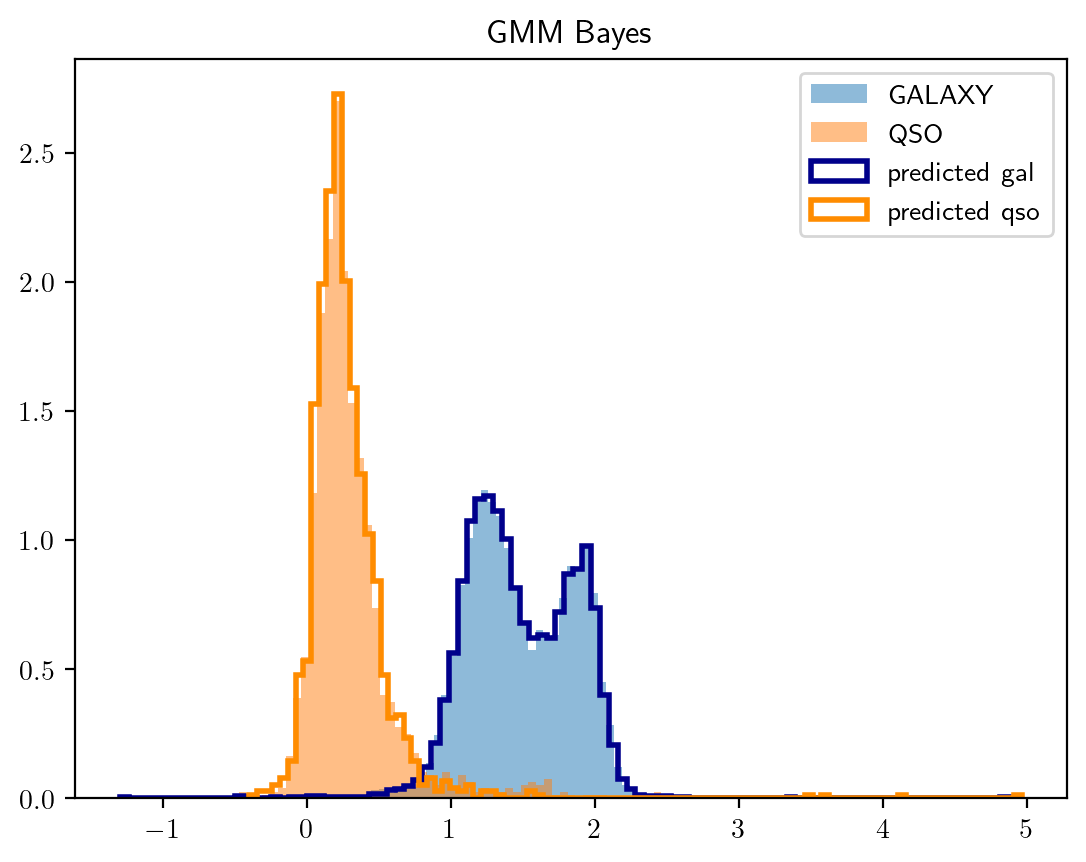

In [128]:
# results with GMM Bayesian classifier

X = np.array(colors).T
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
gmmb = GMMBayes(4) # clusters per class
gmmb.fit(X_train,y_train)
y_pred = gmmb.predict(X_test)

_ = plt.hist(X_test[y_test == 0, 0], bins = 100, density = True, label = 'GALAXY', alpha = 0.5, lw = 2)
_ = plt.hist(X_test[y_test == 1, 0], bins = 100, density = True, label = 'QSO', alpha = 0.5, lw = 2)
_ =plt.hist(X_test[y_pred == 0, 0], bins = 100, density = True, label = 'predicted gal', histtype = 'step', lw = 2, color = 'darkblue')
_ = plt.hist(X_test[y_pred == 1, 0], bins = 100, density = True, label = 'predicted qso', histtype='step', lw = 2, color = 'darkorange')
plt.legend()
plt.title('GMM Bayes')

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:')
print(cm)
print('Accuracy =', np.trace(cm)/len(y_test))